In [1]:
# general imports
from pathlib import Path
from dotenv import find_dotenv, load_dotenv
import numpy as np
import os

# keras and tensorflow imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from keras.applications.efficientnet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetV2S

# experiment tracking imports
import wandb
from wandb.integration.keras import WandbMetricsLogger

# visualization imports
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

# shap imports
import shap

## Set main variables

In [2]:
load_dotenv(find_dotenv(usecwd=True))

# Training hyperparameters
BATCH_SIZE = 32
LEARNING_RATE = 1e-05
EPOCHS = 15

DATA_ROOT = Path(os.getenv(
    "BRAIN_TUMOR_DATA_DIR",
    os.getenv("DATA_ROOT", Path.cwd() / "data" / "raw"),
))
TRAINING_DIR = Path(os.getenv("TRAINING_DATA_DIR", DATA_ROOT / "Training"))
TESTING_DIR = Path(os.getenv("TESTING_DATA_DIR", DATA_ROOT / "Testing"))

MODEL_NAME = "efficientnet_3"
DESCRIPTIVES_DIR = Path.cwd() / "descriptives" / MODEL_NAME
DESCRIPTIVES_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_DIR = Path.cwd() / "checkpoints" / MODEL_NAME
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = CHECKPOINT_DIR / (
    f"{MODEL_NAME}_{BATCH_SIZE}_batchsize_{EPOCHS}_epochs_{LEARNING_RATE}_lr.weights.h5"
)


## Inspect the data

In [3]:
# set up data directories
DATA_ROOT = Path(os.getenv(
    "BRAIN_TUMOR_DATA_DIR",
    os.getenv("DATA_ROOT", Path.cwd() / "data" / "raw"),
))
TRAINING_DIR = Path(os.getenv("TRAINING_DATA_DIR", DATA_ROOT / "Training"))
TESTING_DIR = Path(os.getenv("TESTING_DATA_DIR", DATA_ROOT / "Testing"))

# load and count images per class in training and testing directories
def folder_counts(root):
    return {class_name: len(os.listdir(os.path.join(root, class_name)))
            for class_name in sorted(os.listdir(root))}

print("Training:", folder_counts(TRAINING_DIR))
print("Testing :", folder_counts(TESTING_DIR))


Training: {'glioma_tumor': 826, 'meningioma_tumor': 822, 'no_tumor': 395, 'pituitary_tumor': 827}
Testing : {'glioma_tumor': 100, 'meningioma_tumor': 115, 'no_tumor': 105, 'pituitary_tumor': 74}


## Set data generators for train, val and test

In [4]:
# set up data generators for training, validation, and testing
# All notebooks use the same split, image size, batch size, and preprocessing.
train_gen = ImageDataGenerator(
    validation_split=0.2,
    preprocessing_function=preprocess_input,
)

train_flow = train_gen.flow_from_directory( # apply the model-specific preprocessing function
    str(TRAINING_DIR),
    target_size=(256, 256), # resize images to 256x256 pixels 
    batch_size=BATCH_SIZE,  # batch size for the data generator
    class_mode="categorical",
    subset="training",
    shuffle=True, # shuffle data to ensure randomness in training
)

valid_flow = train_gen.flow_from_directory(
    str(TRAINING_DIR),
    target_size=(256, 256),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False, # do not shuffle data to maintain order for evaluation
)

test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_flow = test_gen.flow_from_directory(
    str(TESTING_DIR),
    target_size=(256, 256),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False, # do not shuffle data to maintain order for evaluation
)


Found 2297 images belonging to 4 classes.


Found 573 images belonging to 4 classes.
Found 394 images belonging to 4 classes.


## Compute class weights

In [5]:
# compute class weights to reduce class imbalance issues 

# this function estimates class weights for unbalanced datasets
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_flow.classes), # input the unique class labels from the training data
    y=train_flow.classes # array of original class labels per sample
)

class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict) # print the class weights to inspect the computed values


{0: 0.8687594553706506, 1: 0.8727203647416414, 2: 1.817246835443038, 3: 0.8674471299093656}


## Load pretrained model

In [6]:
# by default, the loaded model will include the original CNN 
# classifier designed for the ImageNet dataset
# since we want to reuse this model for a different problem,
# we need to omit the original fully connected layers, and 
# replace them with our own setting include_top = False will
# load the model without the fully connected layer

# load EfficientNetV2S model, with pretrained imagenet weights.
res = EfficientNetV2S(weights ='imagenet', 
                      include_top = False, # load the model without the final layer (the classifier) so we can add our own
                      input_shape =(256, 256, 3)) # our images are 256x256 pixels with 3 color channels (RGB)

# freeze the entire backbone
# keeps the original weights
res.trainable = False


2026-09-30 15:12:43.750205: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-09-30 15:12:43.750240: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-09-30 15:12:43.750245: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1790773963.750698 6297304 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1790773963.750769 6297304 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [7]:
# unfreeze only the final stage of the backbone
# For EfficientNetV2-S the final stage is block 6 (the last MBConv group) plus the top conv/bn

for layer in res.layers:
    layer.trainable = layer.name.startswith(('block6', 'top')) # define trainable layers

# sanity check: displaying which part of the backbone is unfrozen
unfrozen = [l.name for l in res.layers if l.trainable]
print(f"Unfrozen {len(unfrozen)} backbone layers (final stage)")
print(f"  first: {unfrozen[0]}   last: {unfrozen[-1]}")

Unfrozen 226 backbone layers (final stage)
  first: block6a_expand_conv   last: top_activation


## Define model

In [8]:
model = models.Sequential([
    res, # base model with pretrained weights
    layers.GlobalAveragePooling2D(), # global average pooling layer to reduce the spatial dimensions of the feature maps. TODO: Review
    layers.BatchNormalization(), # normalization layer to stabilize and accelerate training
    layers.Dense(256, activation='relu'), # fully connected layer with 256 units and ReLU activation
    layers.Dropout(0.4), # dropout layer to prevent overfitting
    layers.Dense(128, activation='relu'), # fully connected layer with 128 units and ReLU activation
    layers.Dropout(0.3), #  dropout layer to prevent overfitting
    layers.Dense(4, activation='softmax') # num_classes, activation
    ], name='BrainTumor_EfficientNetV2S') # custom model name for tracking performance

# first callback: early stopping to avoid overfitting
callback = keras.callbacks.EarlyStopping(monitor="val_recall", # maximizing recall to minimize false negatives (FN) and avoid missing any tumor cases
                                         patience=5, # number of epochs to wait before stopping
                                         verbose=1, # logging
                                         restore_best_weights=True) # TODO: Review this parameter


# second callback: save the best validation-loss weights to reuse in the future without retraining the model
callback_save_model = keras.callbacks.ModelCheckpoint(
    filepath=CHECKPOINT_PATH, # path to save the best model weights
    monitor="val_recall", # maximizing validation recall to minimize false negatives (FN) and avoid missing any tumor cases
    mode="max",
    save_best_only=True,
    save_weights_only=True,
    verbose=1,
)


model.compile( # compile the model with the Adam optimizer, categorical crossentropy loss, and accuracy, precision, and recall metrics
    optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE), 
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy', 'precision', 'recall']
)


In [12]:
model.summary()


Model: "BrainTumor_EfficientNetV2S"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-s (Functional)   │ (None, 8, 8, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,697,828 (78.96 MB)

 Trainable params: 15,255,980 (58.20 MB)

 Non-trainable params: 5,441,848 (20.76 MB)

In [9]:
total_params     = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"\nTotal Parameters    : {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")



Total Parameters    : 20,697,828
Trainable Parameters: 15,255,980


## Train and save the model

In [10]:
# train the model 

# set up wandb for experiment tracking and logging
wandb.init(
    project="brain-tumor-detection",
    name="efficientnet-deeper-head",
    config={
        "backbone": "EfficientNetV2S",
        "unfreeze": "block6+top",
        "head": "256-128",     
        "dropout": "yes",
        "epochs": EPOCHS,
        "optimizer": "Adam",
        "lr": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "augmentation": False,
    },
)


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/caro/.netrc.
wandb: Currently logged in as: carobrasor (aml4ds) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [11]:
history = model.fit( # train the model with the training data, validation data, class weights, and callbacks
    train_flow, # training data generator
    epochs=EPOCHS, # epochs to train the model for
    validation_data=valid_flow, # validation data generator
    class_weight=class_weight_dict, # previously calculated class weights to address class imbalance   
    callbacks=[WandbMetricsLogger(), callback, callback_save_model], # callbacks for logging, early stopping, and saving the best model weights
)

Epoch 1/15


2026-09-30 15:14:39.117328: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3291 - loss: 2.7110 - precision: 0.3346 - recall: 0.3034
Epoch 1: val_recall improved from None to 0.17801, saving model to /Users/caro/Desktop/GITHUB-REPOS/brain-tumor-detection/notebooks/checkpoints/efficientnet_3/efficientnet_3_32_batchsize_15_epochs_1e-05_lr.weights.h5

Epoch 1: finished saving model to /Users/caro/Desktop/GITHUB-REPOS/brain-tumor-detection/notebooks/checkpoints/efficientnet_3/efficientnet_3_32_batchsize_15_epochs_1e-05_lr.weights.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 211s 3s/step - accuracy: 0.3291 - loss: 2.7110 - precision: 0.3346 - recall: 0.3034 - val_accuracy: 0.4276 - val_loss: 1.2739 - val_precision: 0.5514 - val_recall: 0.1780
Epoch 2/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4393 - loss: 2.0550 - precision: 0.4502 - recall: 0.4149
Epoch 2: val_recall improved from 0.17801 to 0.35079, saving model to /Users/caro/Desktop/GITHUB-REPOS/brain-tumor-detection/notebooks/checkpoints/efficientnet_3/efficient

## Load model

In [12]:
# Reload the saved best weights in a fresh kernel without rerunning model.fit()

# raise error if model does not exist, otherwise load the weights
if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"No saved weights found at {CHECKPOINT_PATH}. Run the training cell first."
    )
model.load_weights(CHECKPOINT_PATH)
print(f"Loaded weights from {CHECKPOINT_PATH}")

# initialize wandb again to log the evaluation metrics for the best model weights
wandb.init(
    project="brain-tumor-detection",
    name="efficientnet-deeper-head",
    config={
        "backbone": "EfficientNetV2S",
        "unfreeze": "block6+top",
        "head": "256-128",     
        "dropout": "yes",
        "epochs": EPOCHS,
        "optimizer": "Adam",
        "lr": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "augmentation": False,
    },
)



Loaded weights from /Users/caro/Desktop/GITHUB-REPOS/brain-tumor-detection/notebooks/checkpoints/efficientnet_3/efficientnet_3_32_batchsize_15_epochs_1e-05_lr.weights.h5


epoch/accuracy,▁▃▄▅▅▆▆▇▇▇▇▇███
epoch/epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▅▄▃▃▂▂▂▂▂▁▁▁▁
epoch/precision,▁▃▄▅▅▆▆▇▇▇▇▇███
epoch/recall,▁▃▄▅▅▆▆▇▇▇▇▇███
epoch/val_accuracy,▁▃▄▄▅▅▆▆▆▇▇▇███
epoch/val_loss,█▆▆▆▅▅▅▄▅▄▃▃▁▂▂
epoch/val_precision,▁▂▃▃▄▄▅▅▆▆▇▇███
epoch/val_recall,▁▃▅▅▆▆▇▇▇▇▇████
epoch/accuracy,0.80845


Best validation accuracy: 0.7574 (75.74%)
Best validation precision: 0.7624 (76.24%)
Best validation recall: 0.7504 (75.04%)


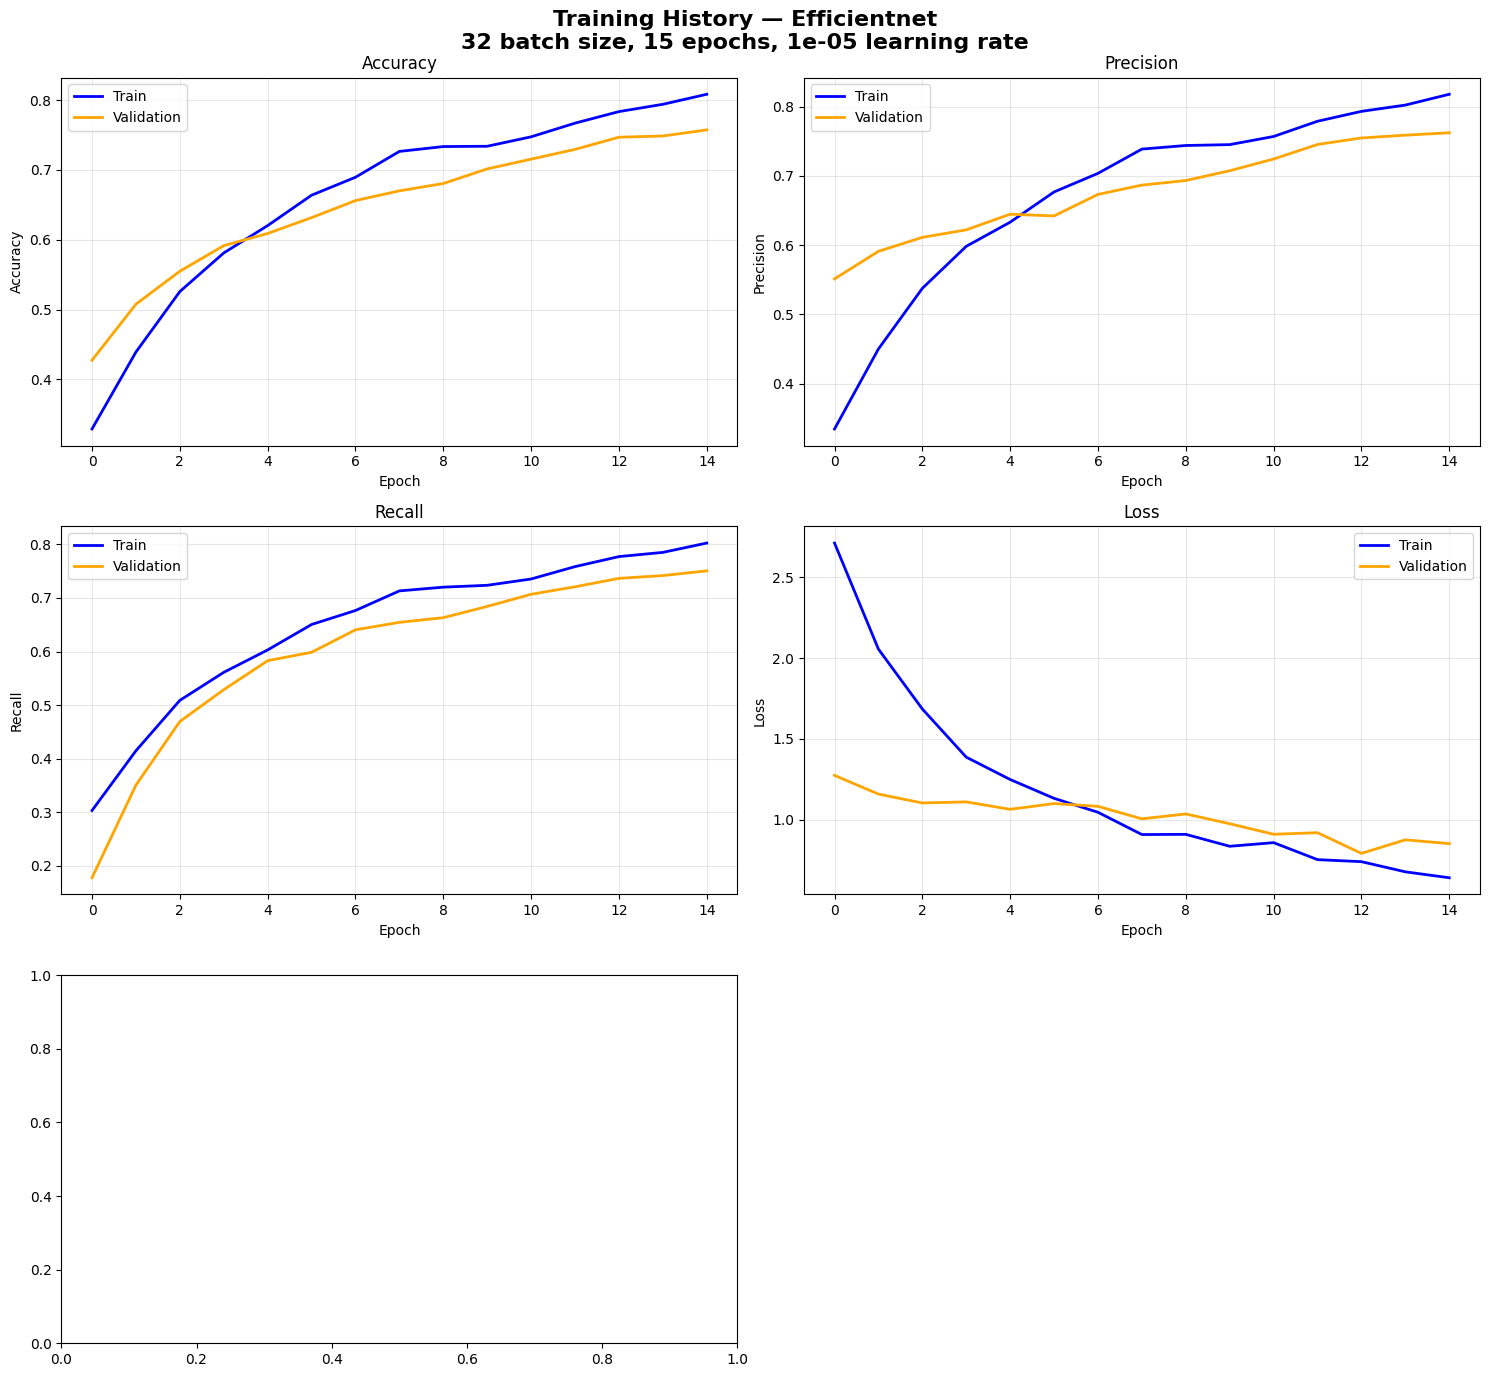

Consolidated training history saved


In [13]:
# Consolidated training history

best_metrics = {
    metric: max(history.history[f"val_{metric}"])
    for metric in ("accuracy", "precision", "recall")
}

for metric, value in best_metrics.items():
    print(f"Best validation {metric}: {value:.4f} ({value*100:.2f}%)")

fig, axes = plt.subplots(3, 2, figsize=(15, 14))
fig.suptitle(f"Training History — Efficientnet\n{BATCH_SIZE} batch size, {EPOCHS} epochs, {LEARNING_RATE} learning rate", fontsize=16, fontweight="bold")

metrics = ["accuracy", "precision", "recall", "loss"]

for ax, metric in zip(axes.flat, metrics):
    ax.plot(history.history[metric], label="Train", color="blue", lw=2)
    ax.plot(
        history.history[f"val_{metric}"],
        label="Validation",
        color="orange",
        lw=2,
    )
    ax.set_title(metric.replace("_", " ").title())
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric.replace("_", " ").title())
    ax.legend()
    ax.grid(True, alpha=0.3)

axes.flat[-1].axis("off")
plt.tight_layout()

plt.savefig(
    DESCRIPTIVES_DIR
    / f"training_history_{MODEL_NAME}_{BATCH_SIZE}_batchsize_"
      f"{EPOCHS}_epochs_{LEARNING_RATE}_lr.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()
print("Consolidated training history saved")


In [14]:
result = model.evaluate(test_flow)

print('The model achieved a loss of %.2f and,'
      'accuracy of %.2f%%.' % (result[0], result[1]*100))

wandb.log({"test_loss": result[0], "test_accuracy": result[1]})
wandb.finish()


13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 889ms/step - accuracy: 0.6777 - loss: 1.6846 - precision: 0.6831 - recall: 0.6675
The model achieved a loss of 1.68 and,accuracy of 67.77%.


test_accuracy,▁
test_loss,▁
test_accuracy,0.67766
test_loss,1.68462


## Predict on test set

In [15]:
def predict_with_threshold(probs, no_tumor_threshold):
    "Favors predicting tumor even when no tumor was initially predicted"
    preds = np.argmax(probs, axis=1)
    # TODO: CONTINUE AND PREDICT WITH THRESHOLD
    return preds

probs = model.predict(test_flow)              # shape: (n_samples, 4)
y_pred = np.argmax(probs, axis=1)             # predicted class index per image: max probability per row
y_true = test_flow.classes                    # true class index per image
class_names = list(test_flow.class_indices.keys())   # ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


13/13 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step 


### Get descriptives on test set predictions

TODO: Add interpretation

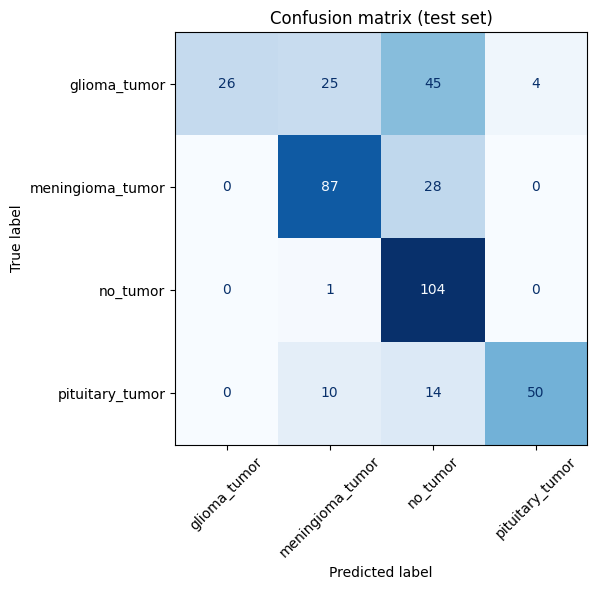

In [16]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
plt.title("Confusion matrix (test set)")
plt.tight_layout(); plt.show()


## Show correct and incorrect classifications

In [17]:
def show_examples(true_cls, pred_cls, n=6):
    """Show n images where true class == true_cls and predicted == pred_cls."""
    idxs = np.where((y_true == true_cls) & (y_pred == pred_cls))[0]
    if len(idxs) == 0:
        print(f"No samples: true={class_names[true_cls]}, predicted={class_names[pred_cls]}")
        return
    idxs = idxs[:n]

    fig, axes = plt.subplots(1, len(idxs), figsize=(3*len(idxs), 3))
    if len(idxs) == 1:
        axes = [axes]

    filenames = test_flow.filenames
    for ax, i in zip(axes, idxs):
        img_path = os.path.join(test_flow.directory, filenames[i])
        img = plt.imread(img_path)
        ax.imshow(img, cmap='gray')
        ax.set_title(f"conf={probs[i, pred_cls]:.2f}", fontsize=9)
        ax.axis('off')
    fig.suptitle(f"true: {class_names[true_cls]}  →  predicted: {class_names[pred_cls]}", y=1.05)
    plt.tight_layout(); plt.show()


Correct predictions for class 'glioma_tumor':


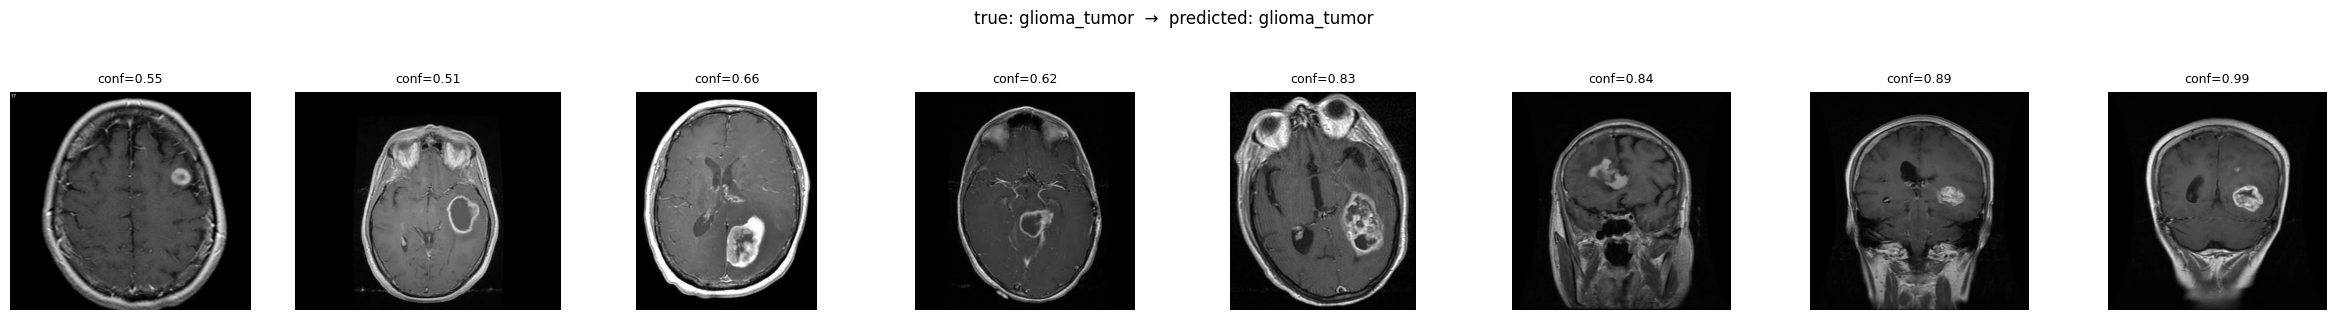

Correct predictions for class 'meningioma_tumor':


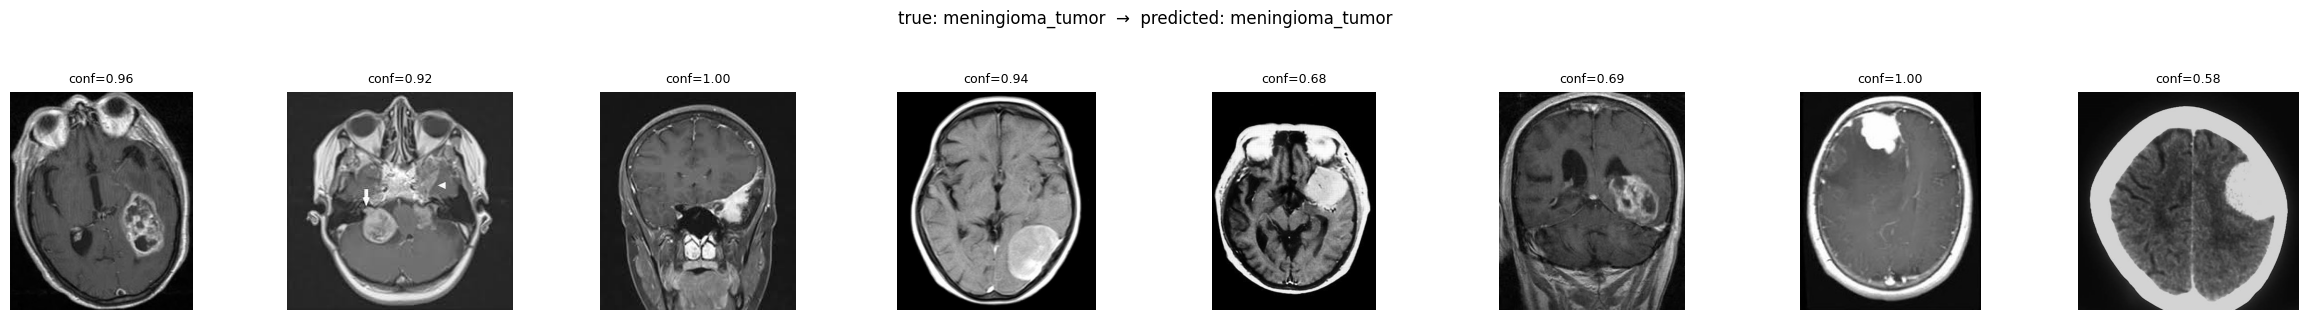

Correct predictions for class 'no_tumor':


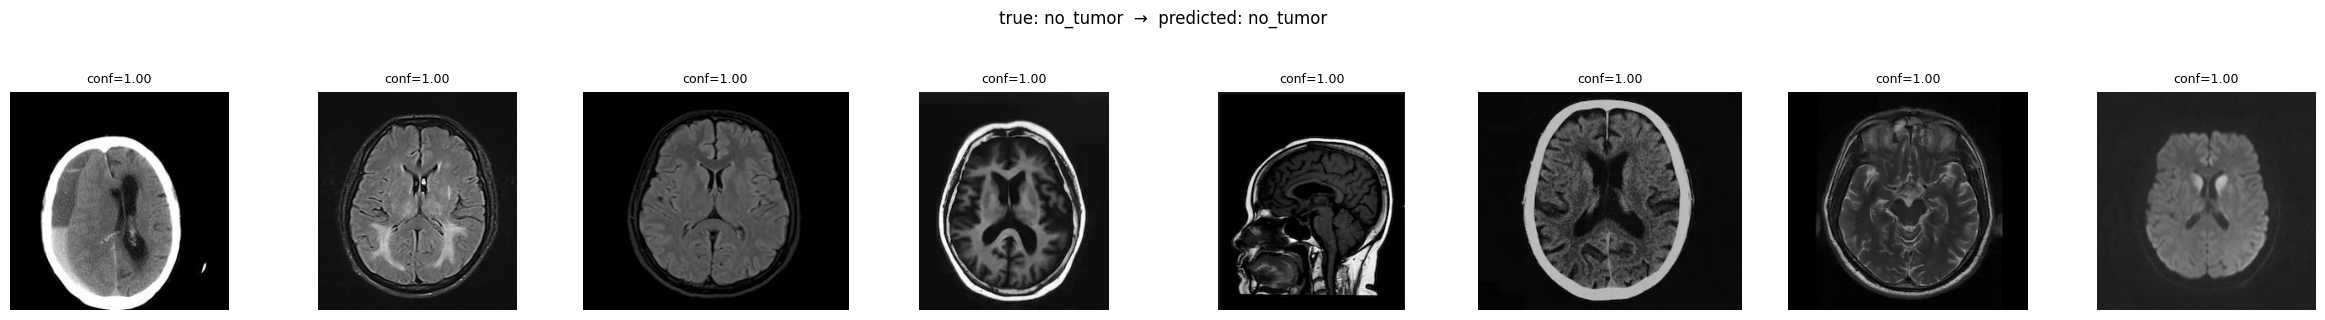

Correct predictions for class 'pituitary_tumor':


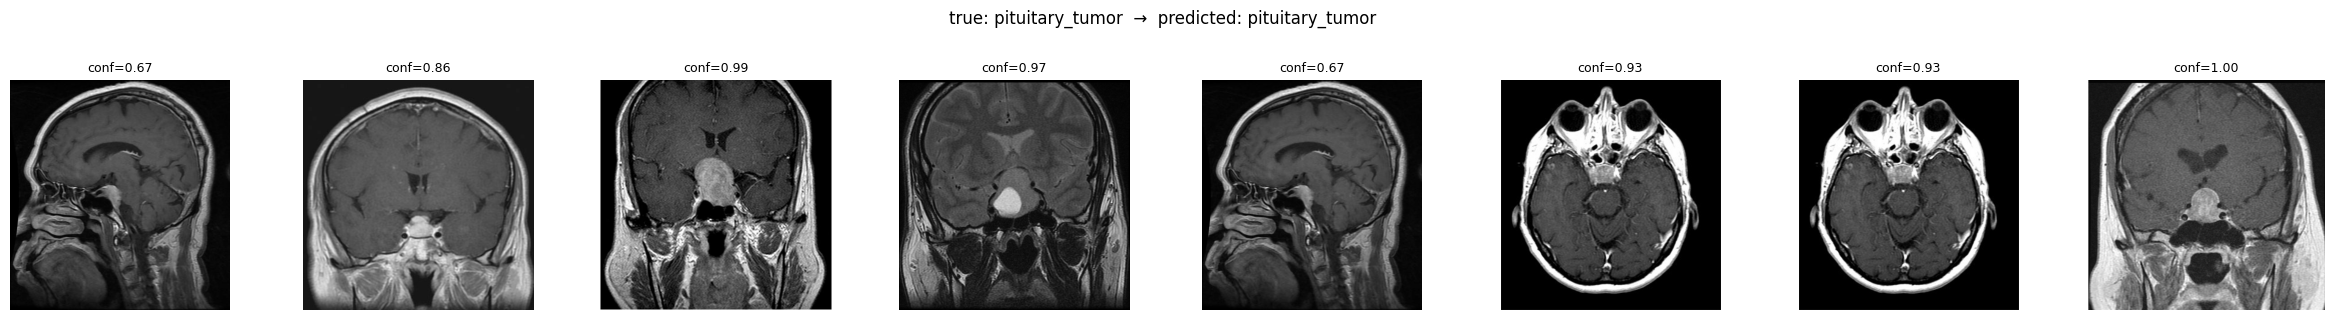

In [18]:
# Correct predictions (diagonal) — sanity check
for c in range(4):
    print(f"Correct predictions for class '{class_names[c]}':")
    show_examples(true_cls=c, pred_cls=c, n=8)

All mistakes for the 'glioma' class (true: glioma_tumor):


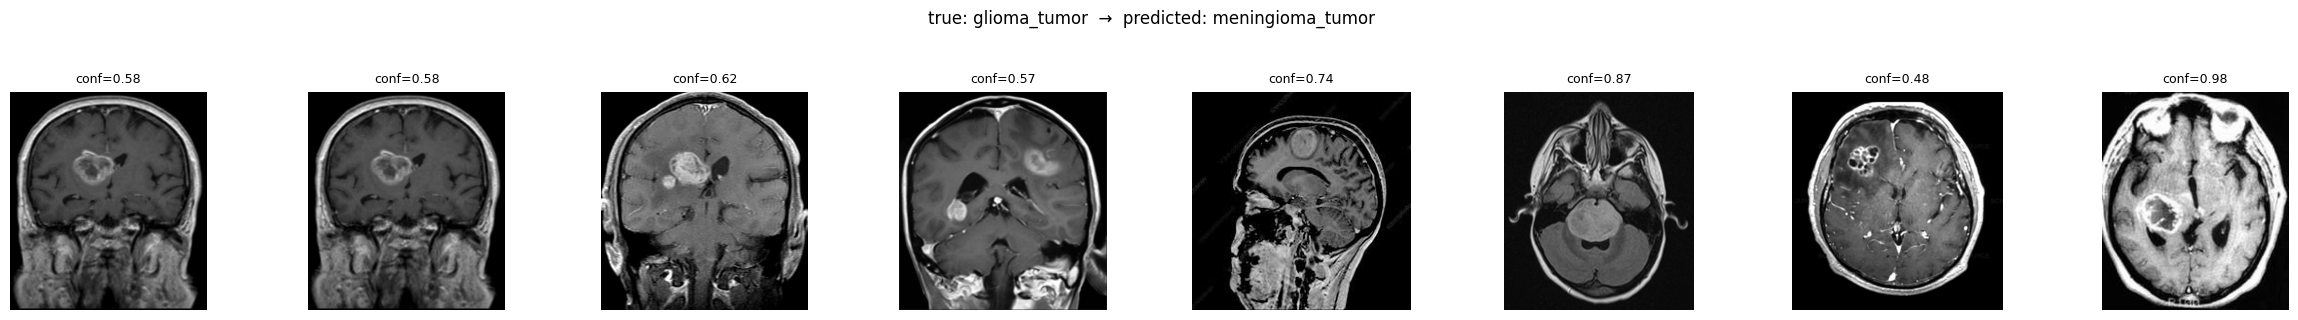

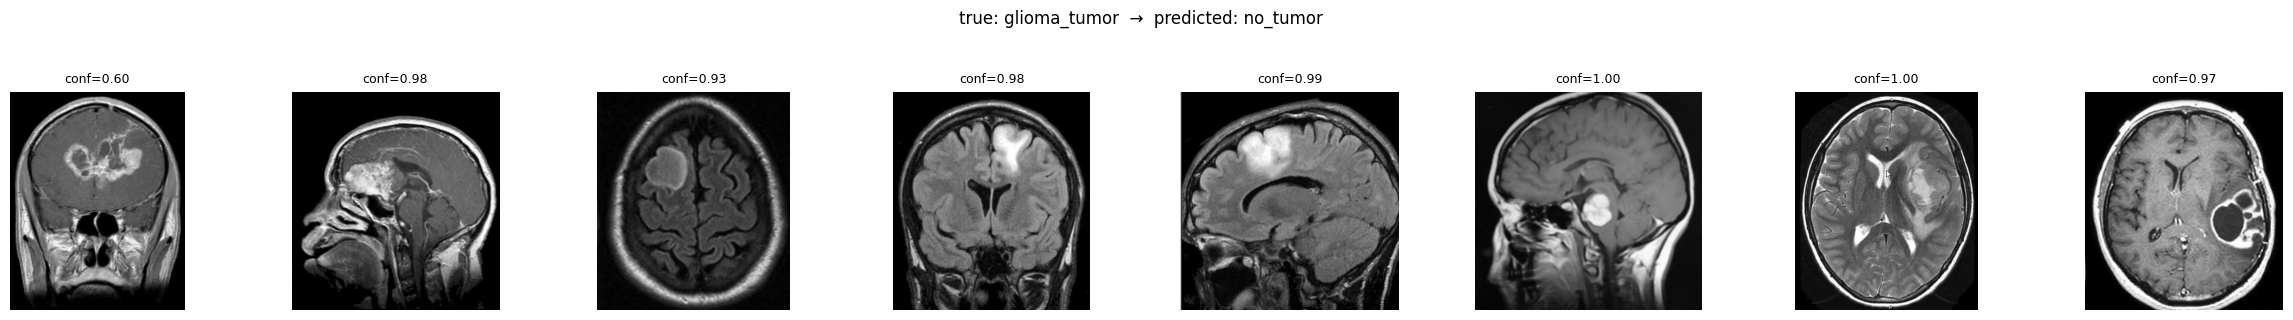

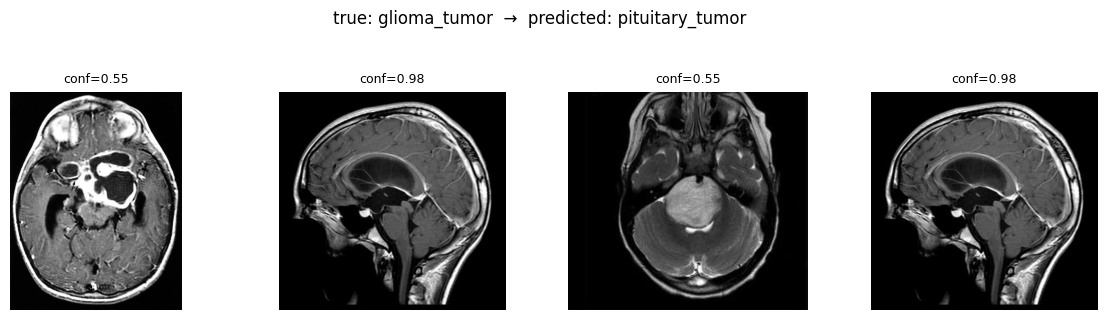

In [19]:
# All mistakes for the "glioma" class (row 0, off-diagonal)
print(f"All mistakes for the 'glioma' class (true: {class_names[0]}):")
for pred in range(4):
    if pred != 0:
        show_examples(true_cls=0, pred_cls=pred, n=8)

All mistakes for the 'meningioma' class (true: meningioma_tumor):
No samples: true=meningioma_tumor, predicted=glioma_tumor


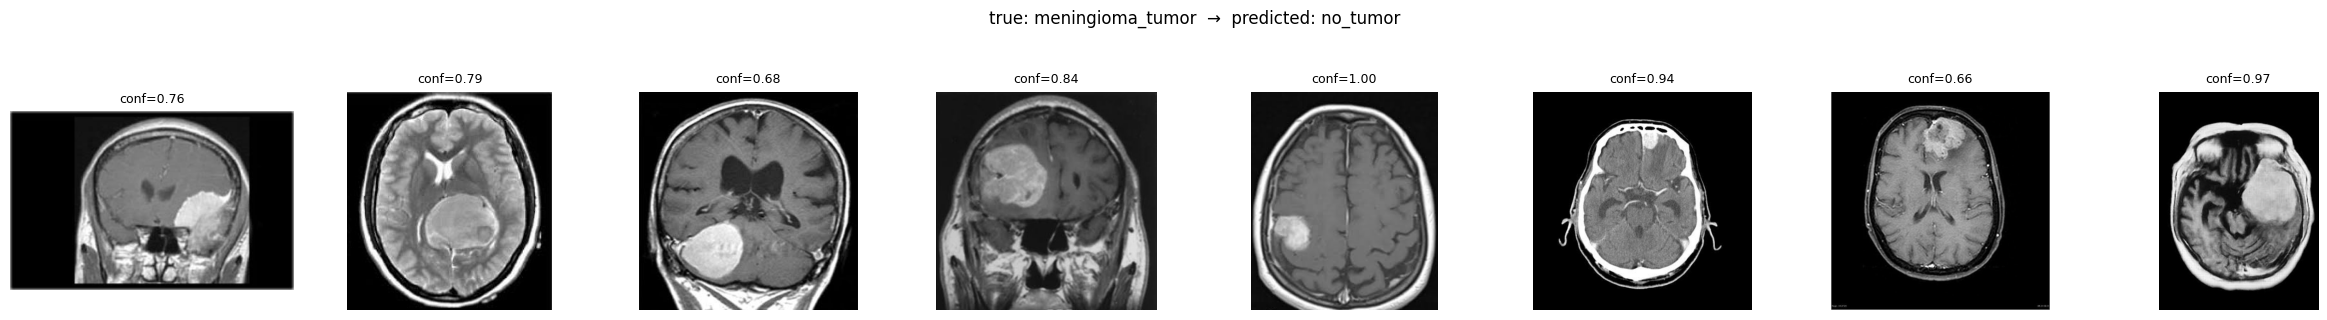

No samples: true=meningioma_tumor, predicted=pituitary_tumor


In [20]:
# All mistakes for the "meningioma" class (row 0, off-diagonal)
print(f"All mistakes for the 'meningioma' class (true: {class_names[1]}):")
for pred in range(4):
    if pred != 1:
        show_examples(true_cls=1, pred_cls=pred, n=8)

All mistakes for the 'pituitary' class (true: pituitary_tumor):
No samples: true=pituitary_tumor, predicted=glioma_tumor


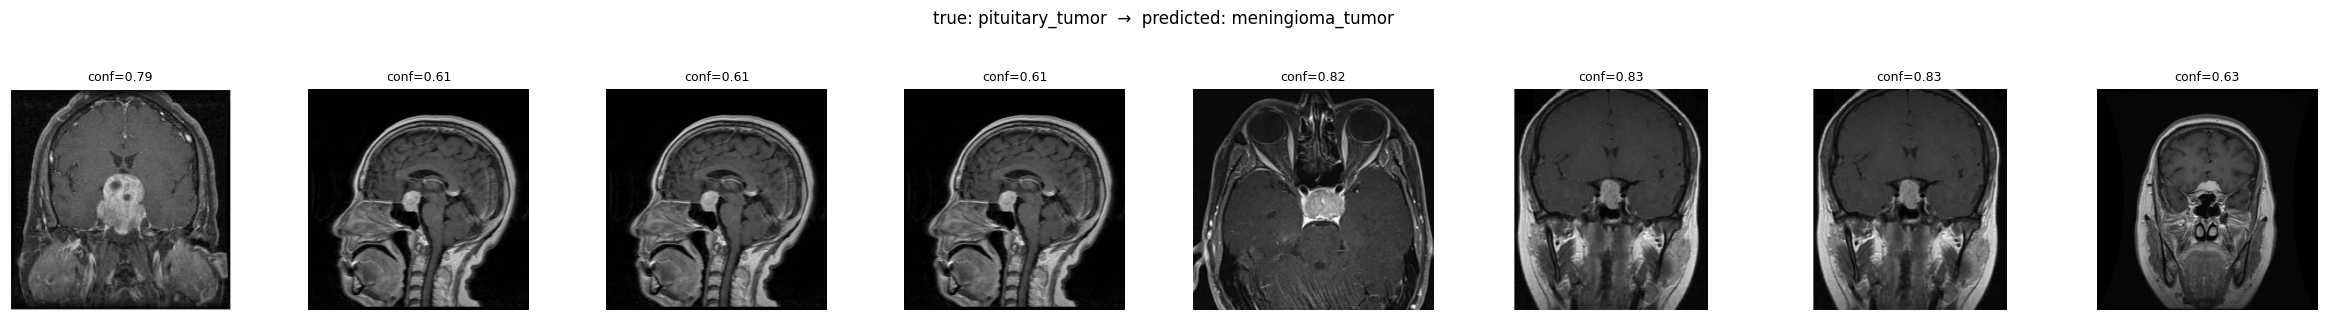

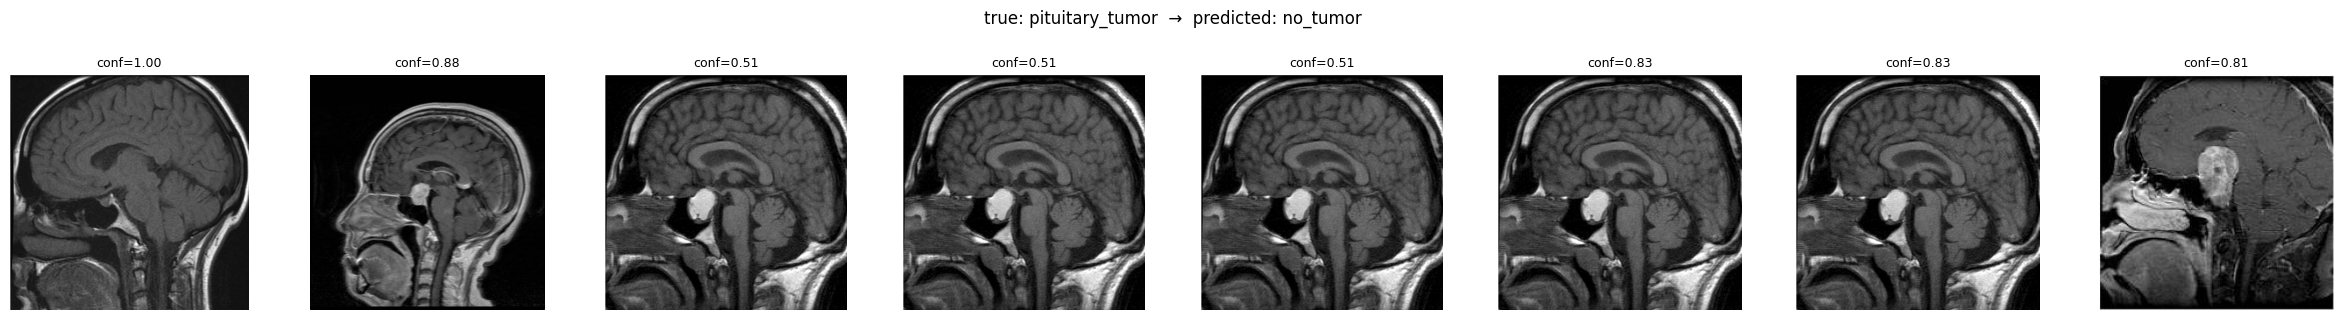

In [21]:
# All mistakes for the "pituitary" class (row 0, off-diagonal)
print(f"All mistakes for the 'pituitary' class (true: {class_names[3]}):")
for pred in range(4):
    if pred != 3:
        show_examples(true_cls=3, pred_cls=pred, n=8)

All false positives for the 'no_tumor' class (predicted: no_tumor):


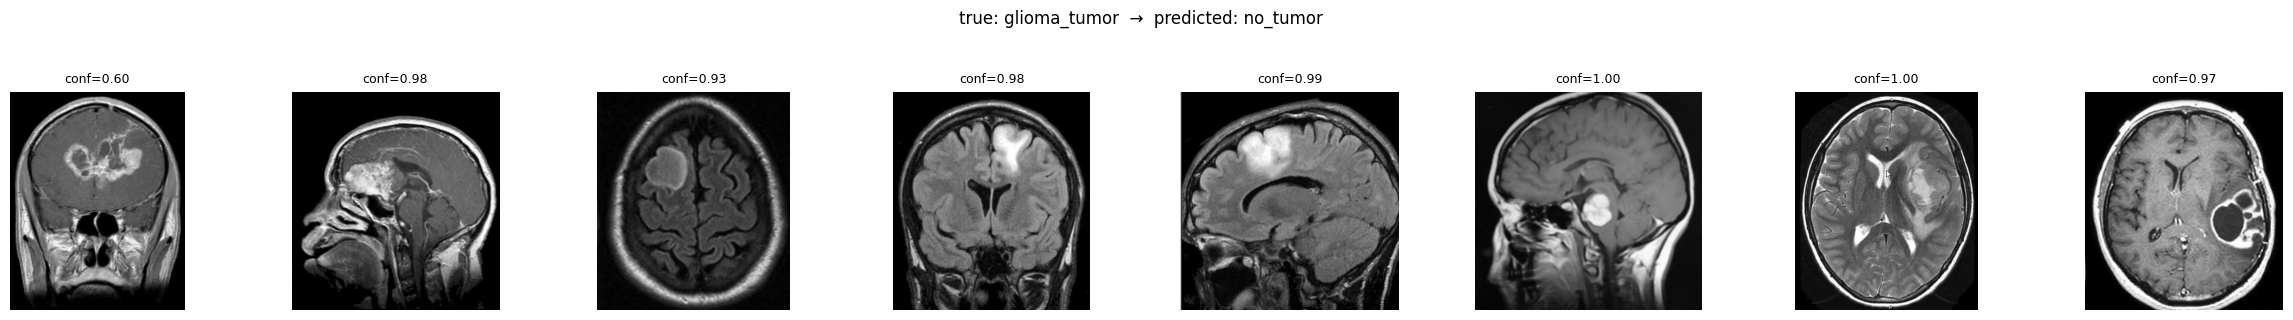

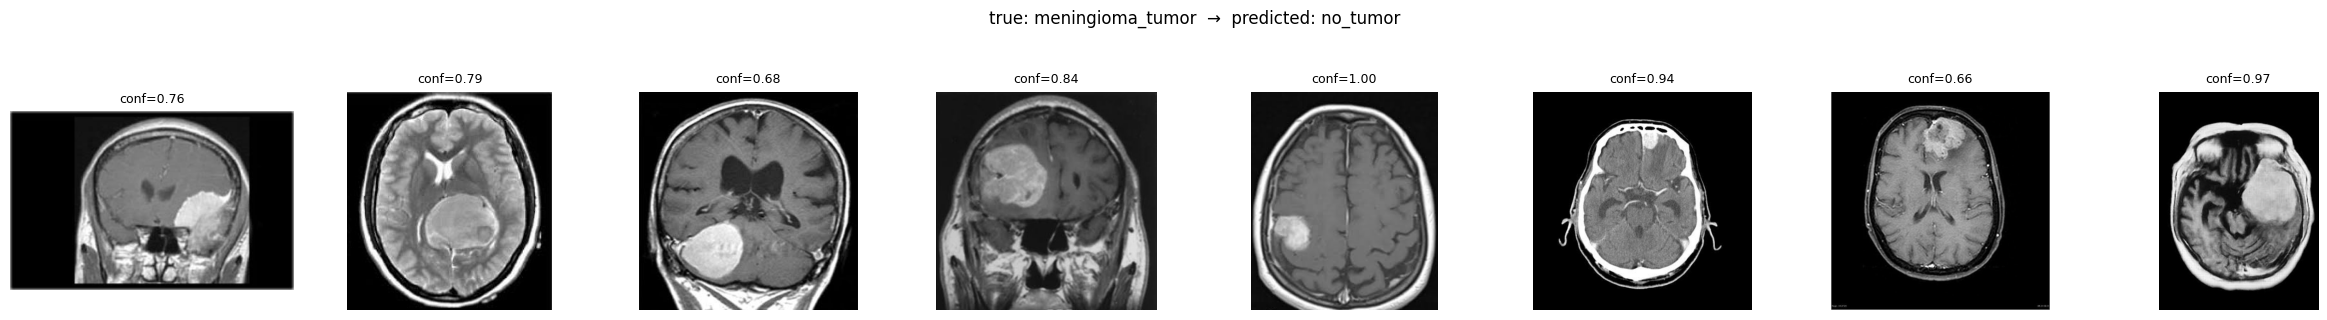

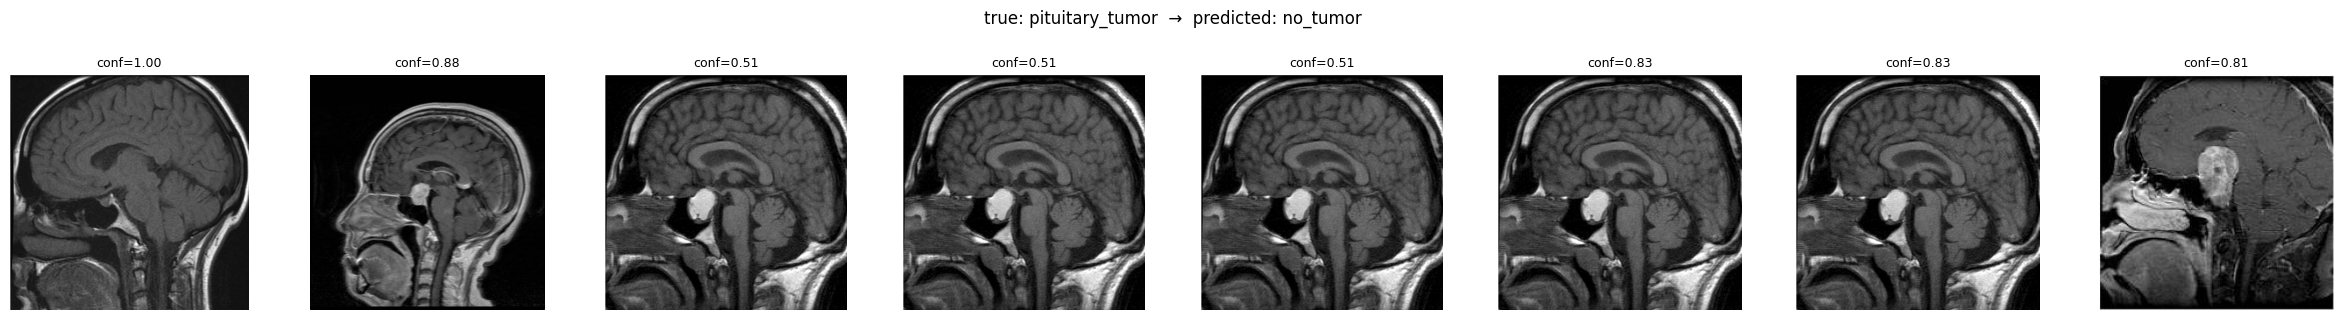

In [22]:

# All false positives for "no_tumor" (column 2, off-diagonal) — these are the dangerous ones in a medical context
print(f"All false positives for the 'no_tumor' class (predicted: {class_names[2]}):")
for true in range(4):
    if true != 2:
        show_examples(true_cls=true, pred_cls=2, n=8)

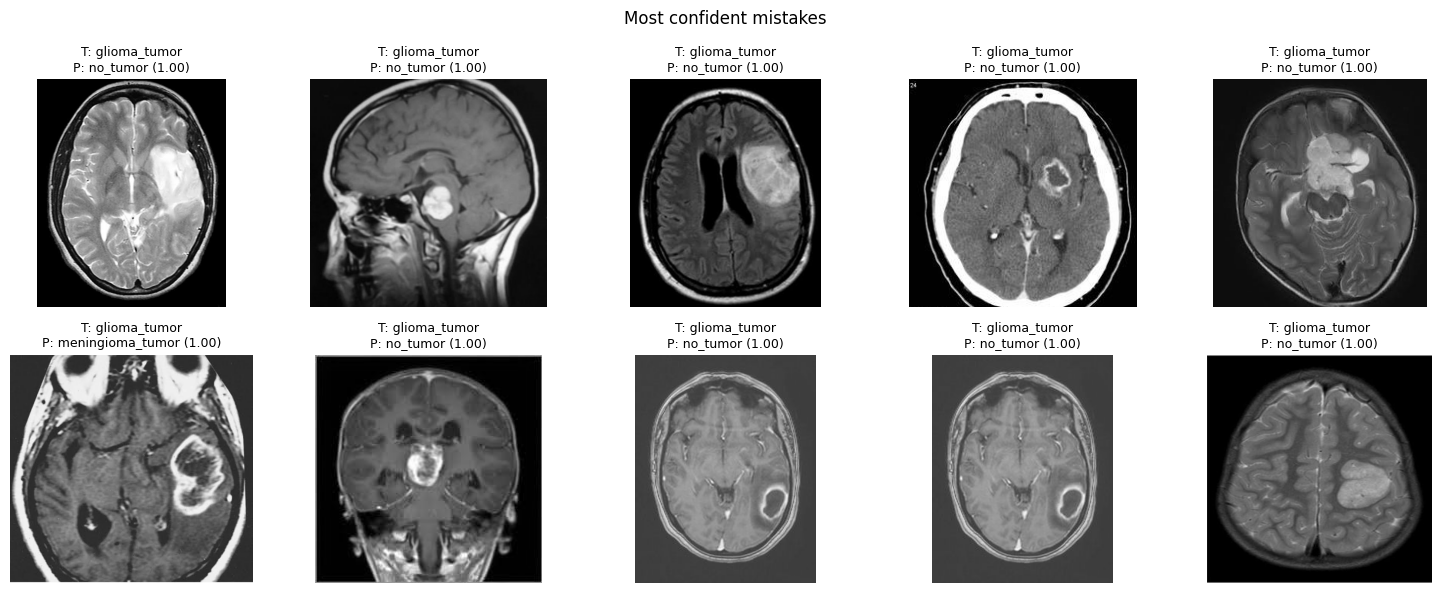

In [23]:
wrong = np.where(y_pred != y_true)[0]
confidence_in_wrong_answer = probs[wrong, y_pred[wrong]]
top_wrong = wrong[np.argsort(-confidence_in_wrong_answer)][:10]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, i in zip(axes.flat, top_wrong):
    img = plt.imread(os.path.join(test_flow.directory, test_flow.filenames[i]))
    ax.imshow(img, cmap='gray')
    ax.set_title(f"T: {class_names[y_true[i]]}\nP: {class_names[y_pred[i]]} ({probs[i, y_pred[i]]:.2f})",
                 fontsize=9)
    ax.axis('off')
plt.suptitle("Most confident mistakes")
plt.tight_layout(); plt.show()

## SHAP

Pixels with positive values are shown in red, while pixels with negative values are shown in blue. This means that red pixels has a positive contribution to a specific class. Grey-ish pixels are close to 0, indicating that the model does not pay much attention to these pixels.

SHAP needs a masker to perturb the input images. A masker is a function that takes an input image and returns a perturbed version of it in which some parts are blurred or blacked out. shap.Explainer uses these perturbed versions to measure how much each pixel contributes to the model prediction

In [24]:
# Collect all preprocessed test images into one array (test_flow has shuffle=False, so order matches y_true)
test_flow.reset()
all_imgs = np.concatenate([next(test_flow)[0] for _ in range(len(test_flow))], axis=0) # concatenate batches into one array
print("Test images shape:", all_imgs.shape)   # expect (394, 256, 256, 3)

# SHAP wants a numpy-returning prediction function
def f(x):
    return model.predict(x, verbose=0)

# Masker that blurs masked-out pixels
masker_blur = shap.maskers.Image("blur(32,32)", all_imgs[0].shape)

# 4 classes, not 3
explainer = shap.Explainer(f, masker_blur, output_names=class_names)


Test images shape: (394, 256, 256, 3)


Filename:  glioma_tumor/image(54).jpg
True:      glioma_tumor
Predicted: meningioma_tumor

Class probabilities:
  P(glioma_tumor      ) = 0.0003
  P(meningioma_tumor  ) = 0.8141
  P(no_tumor          ) = 0.1852
  P(pituitary_tumor   ) = 0.0004


  0%|          | 0/1998 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:05, 65.72s/it]               
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


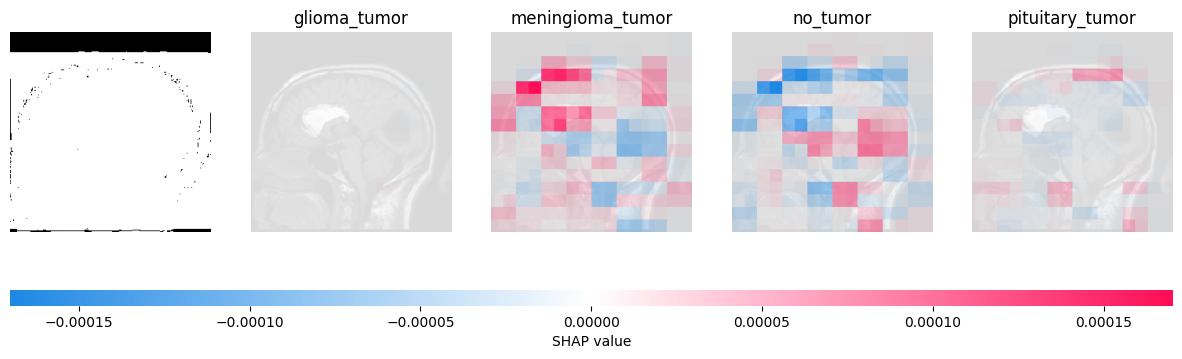

In [25]:
i = 50   # any index in [0, 393]

print(f"Filename:  {test_flow.filenames[i]}")
print(f"True:      {class_names[y_true[i]]}")
print(f"Predicted: {class_names[y_pred[i]]}")
print(f"\nClass probabilities:")
for cls, p in zip(class_names, probs[i]):
    print(f"  P({cls:<18}) = {p:.4f}")

# Pick an image to explain (must be in [0, 393])
ind = [i]           
shap_values_ = explainer(all_imgs[ind], max_evals=2000, batch_size=50)

shap.image_plot(shap_values_)
plt.savefig(DESCRIPTIVES_DIR / f"shap_1_{i}.png", dpi=150, bbox_inches="tight")
plt.close()


Filename:  no_tumor/image(82).jpg
True:      no_tumor
Predicted: no_tumor

Class probabilities:
  P(glioma_tumor      ) = 0.0000
  P(meningioma_tumor  ) = 0.0000
  P(no_tumor          ) = 0.9999
  P(pituitary_tumor   ) = 0.0000


  0%|          | 0/1998 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:28, 28.20s/it]               
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


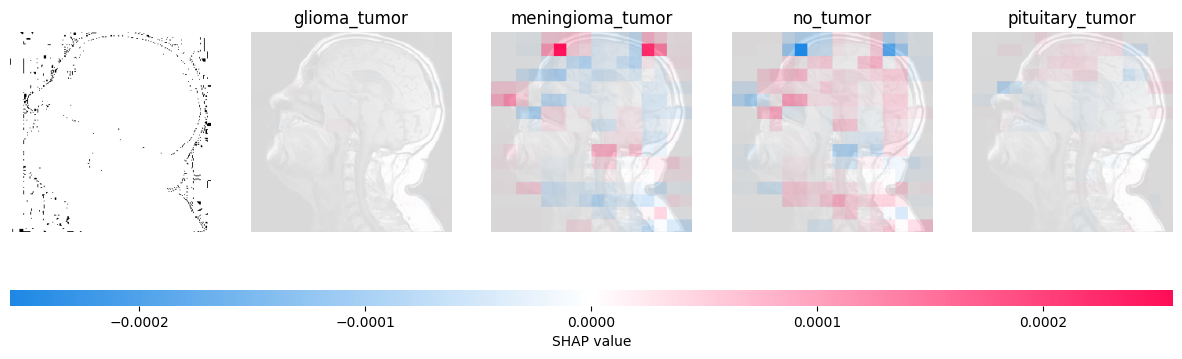

In [26]:
i = 300   # any index in [0, 393]

print(f"Filename:  {test_flow.filenames[i]}")
print(f"True:      {class_names[y_true[i]]}")
print(f"Predicted: {class_names[y_pred[i]]}")
print(f"\nClass probabilities:")
for cls, p in zip(class_names, probs[i]):
    print(f"  P({cls:<18}) = {p:.4f}")

ind = [i]           
shap_values_ = explainer(all_imgs[ind], max_evals=2000, batch_size=50)

shap.image_plot(shap_values_)
plt.savefig(DESCRIPTIVES_DIR / f"shap_2_{i}.png", dpi=150, bbox_inches="tight")
plt.close()


Filename:  glioma_tumor/image(1).jpg
True:      glioma_tumor
Predicted: no_tumor

Class probabilities:
  P(glioma_tumor      ) = 0.0594
  P(meningioma_tumor  ) = 0.3336
  P(no_tumor          ) = 0.5998
  P(pituitary_tumor   ) = 0.0071


  0%|          | 0/49998 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [13:06, 786.82s/it]              
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


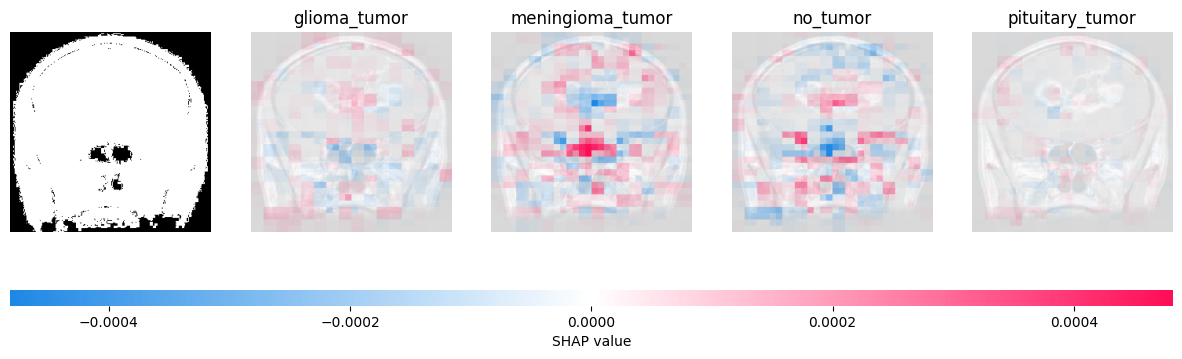

In [ ]:
i = 0   # any index in [0, 393]

print(f"Filename:  {test_flow.filenames[i]}")
print(f"True:      {class_names[y_true[i]]}")
print(f"Predicted: {class_names[y_pred[i]]}")
print(f"\nClass probabilities:")
for cls, p in zip(class_names, probs[i]):
    print(f"  P({cls:<18}) = {p:.4f}")

ind = [i]           
shap_values_ = explainer(all_imgs[ind], max_evals=2000, batch_size=50)

shap.image_plot(shap_values_)
plt.savefig(DESCRIPTIVES_DIR / f"shap_3_{i}.png", dpi=150, bbox_inches="tight")
plt.close()


## Inspect probabilities and predictions

In [31]:
def retrieve_preds_and_output(i):
    print(f"Sample {i}:")
    print(f"  True label: {y_true[i]}")
    print(f"  Predicted label: {y_pred[i]}")
    print(f"  Predicted probability: {probs[i]}")

In [32]:
retrieve_preds_and_output(0)

Sample 0:
  True label: 0
  Predicted label: 2
  Predicted probability: [0.05937287 0.3336404  0.5998428  0.0071439 ]
